In [5]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OrdinalEncoder
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("whitegrid")

In [6]:
df = pd.read_csv("youtube_videos.csv")

In [7]:
df.head()

,video_id,title,category,channel_tier,upload_day,upload_hour,duration_seconds,views,likes,comments,shares,watch_time_minutes,avg_view_duration_seconds,click_through_rate,channel_age_years,subscribers,tags_count,hashtags
0,vid_0000,I tried EVERY transformers tool — the WINNER s...,Music,Mid,Sunday,0,721,228102,9979,2810,1193,1091087,287,0.0100,1.3,441016,18.0,"[""ai"", ""tutorial"", ""trending""]"
1,vid_0001,What nobody tells you about AI image tools,Gaming,Small,Saturday,21,1894,25078,962,283,183,423818,1014,0.0230,0.8,25339,17.0,"[""tutorial""]"
2,vid_0002,What nobody tells you about machine learning p...,Gaming,Large,Monday,18,1413,1323949,6619,25177,16119,12952634,587,0.1022,4.8,2398429,NaN,"[""explained""]"
3,vid_0003,Is Claude worth it in 2025?,Gaming,Mid,Thursday,14,1335,187752,4936,2051,1797,2018334,645,0.0413,3.9,498144,13.0,"[""gaming"", ""trending"", ""explained"", ""tech""]"
4,vid_0004,URGENT: voice cloning AI is about to CHANGE FO...,Music,Small,Monday,4,3158,12583,777,98,30,262565,1252,0.0100,1.3,30039,10.0,"[""explained"", ""shorts""]"


In [8]:
df["subscribers"]

0       441016
1        25339
2      2398429
3       498144
4        30039
        ...   
205      13428
206      10005
207     483919
208      11937
209     553531
Name: subscribers, Length: 210, dtype: int64

In [9]:
scaler = MinMaxScaler()

In [10]:
df["subscribers_minmax"] = scaler.fit_transform(df[["subscribers"]])

In [11]:
df["subscribers_minmax"].describe()

count    210.000000
mean       0.128853
std        0.265999
min        0.000000
25%        0.002555
50%        0.016794
75%        0.061946
max        1.000000
Name: subscribers_minmax, dtype: float64

In [12]:
standard_scaler = StandardScaler()

In [13]:
df["view_zscore"] = standard_scaler.fit_transform(df[["views"]])

In [14]:
df[["views", "view_zscore"]].describe()

,views,view_zscore
count,2.100000e+02,2.100000e+02
mean,5.485440e+05,2.537653e-17
std,1.223751e+06,1.002389e+00
min,1.412000e+03,-4.481625e-01
25%,1.080400e+04,-4.404694e-01
50%,6.597350e+04,-3.952794e-01
75%,3.108772e+05,-1.946757e-01
max,7.038551e+06,5.316044e+00


In [15]:
# Lab task
scaler = MinMaxScaler()
df["comments_minmax"] = scaler.fit_transform(df[["comments"]])
df[["comments", "comments_minmax"]].head()

,comments,comments_minmax
0,2810,0.023553
1,283,0.002342
2,25177,0.211300
3,2051,0.017182
4,98,0.000789


# MinMaxScaler converts the comments column to a 0–1 range
# The smallest comment value becomes 0, the largest becomes 1
# and all other values are scaled proportionally between them

In [16]:
df["views_log"] = np.log1p(df["views"])

<Axes: xlabel='views_log', ylabel='Count'>

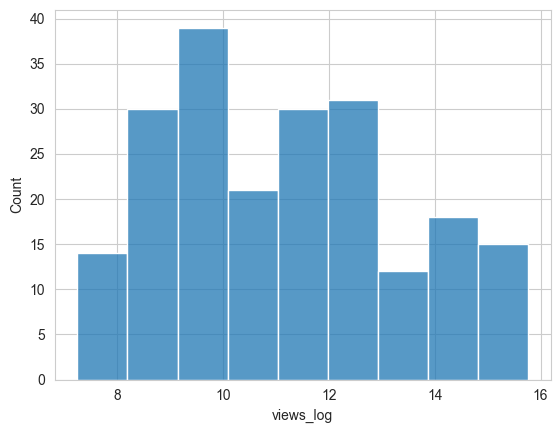

In [17]:
sns.histplot(x=df["views_log"])

<Axes: xlabel='views', ylabel='Count'>

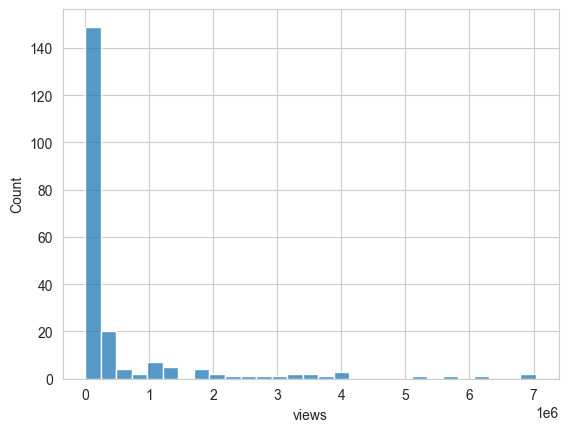

In [18]:
sns.histplot(x=df["views"])

In [19]:
bins = [0, 300, 2000, float("inf")]
labels = ["short", "medium", "long"]

df["duration_bin"] = pd.cut(df["duration_seconds"], bins=bins, labels=labels)

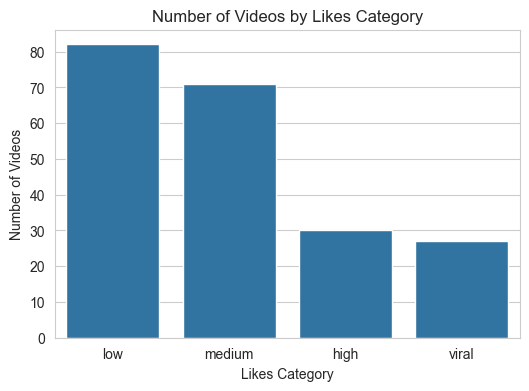

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
bins = [0, 1000, 10000, 50000, float("inf")]
labels = ["low", "medium", "high", "viral"]
df["likes_bin"] = pd.cut(
    df["likes"],
    bins=bins,
    labels=labels,
    include_lowest=True
)
plt.figure(figsize=(6, 4))
sns.countplot(
    data=df,
    x="likes_bin",
    order=labels
)
plt.title("Number of Videos by Likes Category")
plt.xlabel("Likes Category")
plt.ylabel("Number of Videos")
plt.show()

# binning to convert the numeric likes column into categories
# Videos with fewer likes are labelled low or medium, while videos with
# higher likes are labelled high or viral. The bar chart shows how many
# videos fall into each likes category

In [21]:
df["channel_tier"].unique()

<StringArray>
['Mid', 'Small', 'Large']
Length: 3, dtype: str

In [22]:

encoder = OrdinalEncoder(categories=[["Small", "Mid", "Large"]])
df["channel_tier_encoded"] = encoder.fit_transform(df[["channel_tier"]]).astype(int)

In [23]:
df[["channel_tier", "channel_tier_encoded"]]

,channel_tier,channel_tier_encoded
0,Mid,1
1,Small,0
2,Large,2
3,Mid,1
4,Small,0
...,...,...
205,Small,0
206,Small,0
207,Mid,1
208,Small,0


In [24]:
dummyVars = pd.get_dummies(df["category"], prefix="is")

In [25]:
df = pd.concat([df, dummyVars],axis=1)

In [26]:
df

,video_id,title,category,channel_tier,upload_day,upload_hour,duration_seconds,views,likes,comments,...,views_log,duration_bin,likes_bin,channel_tier_encoded,is_Comedy,is_Education,is_Gaming,is_Music,is_News,is_Vlog
0,vid_0000,I tried EVERY transformers tool — the WINNER s...,Music,Mid,Sunday,0,721,228102,9979,2810,...,12.337553,medium,medium,1,False,False,False,True,False,False
1,vid_0001,What nobody tells you about AI image tools,Gaming,Small,Saturday,21,1894,25078,962,283,...,10.129786,medium,low,0,False,False,True,False,False,False
2,vid_0002,What nobody tells you about machine learning p...,Gaming,Large,Monday,18,1413,1323949,6619,25177,...,14.096130,medium,medium,2,False,False,True,False,False,False
3,vid_0003,Is Claude worth it in 2025?,Gaming,Mid,Thursday,14,1335,187752,4936,2051,...,12.142883,medium,medium,1,False,False,True,False,False,False
4,vid_0004,URGENT: voice cloning AI is about to CHANGE FO...,Music,Small,Monday,4,3158,12583,777,98,...,9.440181,long,low,0,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,vid_0205,STOP using Python for AI WRONG (most people do...,Education,Small,Friday,13,1737,6441,147,52,...,8.770594,medium,low,0,False,True,False,False,False,False
206,vid_0206,I built a machine learning pipelines project —...,News,Small,Saturday,8,5776,4755,249,63,...,8.467162,long,low,0,False,False,False,False,True,False
207,vid_0207,What nobody tells you about Gemini,Gaming,Mid,Sunday,20,2617,104852,921,1069,...,11.560315,long,low,1,False,False,True,False,False,False
208,vid_0208,Why deep learning frameworks DESTROYED my work...,Comedy,Small,Thursday,21,3656,3026,165,48,...,8.015327,long,low,0,True,False,False,False,False,False


In [27]:
day_map = {
    "Monday": 0, "Tuesday": 1, "Wednesday": 2,
    "Thursday": 3, "Friday": 4, "Saturday": 5, "Sunday": 6
}
rng = np.random.default_rng(42)
base = pd.Timestamp("2024-01-01")

df["uploaded_at"] = [
    base
    + pd.offsets.Week(weekday=day_map[d])
    + pd.Timedelta(hours=int(h))
    + pd.Timedelta(minutes=int(rng.integers(0, 60)))
    for d, h in zip(df["upload_day"], df["upload_hour"])
]

In [28]:
df["uploaded_at"]

0     2024-01-07 00:05:00
1     2024-01-06 21:46:00
2     2024-01-08 18:39:00
3     2024-01-04 14:26:00
4     2024-01-08 04:25:00
              ...        
205   2024-01-05 13:15:00
206   2024-01-06 08:45:00
207   2024-01-07 20:58:00
208   2024-01-04 21:15:00
209   2024-01-05 10:46:00
Name: uploaded_at, Length: 210, dtype: datetime64[us]

In [29]:
df["uploaded_at"].dt.dayofweek

0      6
1      5
2      0
3      3
4      0
      ..
205    4
206    5
207    6
208    3
209    4
Name: uploaded_at, Length: 210, dtype: int32

In [35]:
df ["caps_count"]= df["title"].apply(
    lambda t: sum(1 for w in t.split() if w.isupper())
)
    

In [36]:
df["caps_count"] 

0      3
1      1
2      0
3      0
4      4
      ..
205    3
206    2
207    0
208    2
209    3
Name: caps_count, Length: 210, dtype: int64

In [37]:
def countCaps(t):
    sum = 0
    words = t.split()
    for word in words:
        if word.isupper():
            sum = sum+1
            return sum

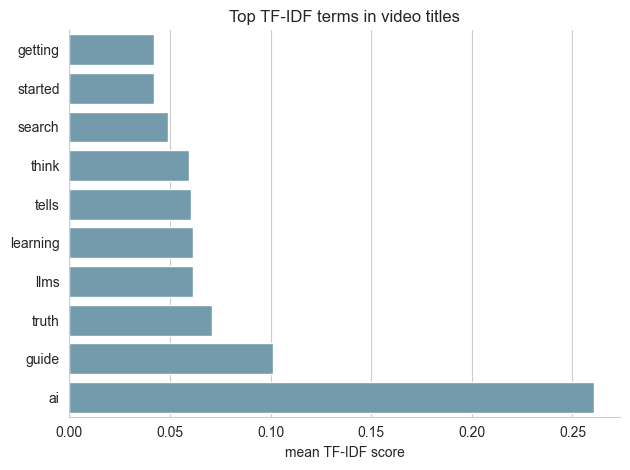

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

df = pd.read_csv("youtube_videos.csv")

vectorizer = TfidfVectorizer(max_features=10, stop_words="english")
tfidf_matrix = vectorizer.fit_transform(df["title"])

terms = vectorizer.get_feature_names_out()
mean_scores = tfidf_matrix.toarray().mean(axis=0)

tfidf_df = pd.DataFrame({
    "term": terms,
    "mean_tfidf": mean_scores
}).sort_values("mean_tfidf", ascending=True)

sns.barplot(data=tfidf_df,
            x="mean_tfidf",
            y="term",
            color="#6a9fb5")

plt.title("Top TF-IDF terms in video titles")
plt.xlabel("mean TF-IDF score")
plt.ylabel("")
sns.despine()
plt.tight_layout()
plt.show()

In [42]:
df ["duration_minutes"] = df ["duration_seconds"] / 60
df["retention_rate"] = df["watch_time_minutes"] / (df["views"] * df["duration_minutes"])

In [43]:
df["retention_rate"]

0      0.398058
1      0.535375
2      0.415428
3      0.483146
4      0.396453
         ...   
205    0.469772
206    0.289126
207    0.495605
208    0.528993
209    0.434620
Name: retention_rate, Length: 210, dtype: float64